In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/dataset.csv')

print(df.shape)
df.head()

(114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [2]:
print(df.info())
print(df.isnull().sum())
print(f"Уникальных треков: {df['track_id'].nunique()}")
print(f"Всего строк: {len(df)}")

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [3]:
print(f"Количество жанров: {df['track_genre'].nunique()}")
genre_counts = df['track_genre'].value_counts()

print(genre_counts)
print(genre_counts.describe())

Количество жанров: 114
track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
trance         1000
trip-hop       1000
turkish        1000
world-music    1000
Name: count, Length: 114, dtype: int64
count     114.0
mean     1000.0
std         0.0
min      1000.0
25%      1000.0
50%      1000.0
75%      1000.0
max      1000.0
Name: count, dtype: float64


In [4]:
print("Полных дубликатов:", df.duplicated().sum())

print("Повторяющихся track_id:",
      df['track_id'].duplicated().sum())

track_genres = df.groupby('track_id')['track_genre'].nunique()

print(track_genres.describe())

print(
    track_genres
    .value_counts()
    .sort_index()
)

Полных дубликатов: 0
Повторяющихся track_id: 24259
count    89741.000000
mean         1.265308
std          0.664204
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          9.000000
Name: track_genre, dtype: float64
track_genre
1    73442
2    11424
3     2955
4     1361
5      431
6      104
7       21
8        2
9        1
Name: count, dtype: int64


In [5]:
print("Loudness:")
print(df['loudness'].describe())

print("\nTempo:")
print(df['tempo'].describe())

Loudness:
count    114000.000000
mean         -8.258960
std           5.029337
min         -49.531000
25%         -10.013000
50%          -7.004000
75%          -5.003000
max           4.532000
Name: loudness, dtype: float64

Tempo:
count    114000.000000
mean        122.147837
std          29.978197
min           0.000000
25%          99.218750
50%         122.017000
75%         140.071000
max         243.372000
Name: tempo, dtype: float64


In [6]:
print("tempo < 50:", (df['tempo'] < 50).sum())
print("tempo > 250:", (df['tempo'] > 250).sum())

print("loudness > 0:", (df['loudness'] > 0).sum())

tempo < 50: 238
tempo > 250: 0
loudness > 0: 90


In [7]:
features = [
    'danceability',
    'energy',
    'key',
    'loudness',
    'mode',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

df[features].describe().T

,count,mean,std,min,25%,50%,75%,max
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996
instrumentalness,114000.0,0.156050,0.309555,0.000,0.00000,0.000042,0.0490,1.000
liveness,114000.0,0.213553,0.190378,0.000,0.09800,0.132000,0.2730,1.000
valence,114000.0,0.474068,0.259261,0.000,0.26000,0.464000,0.6830,0.995


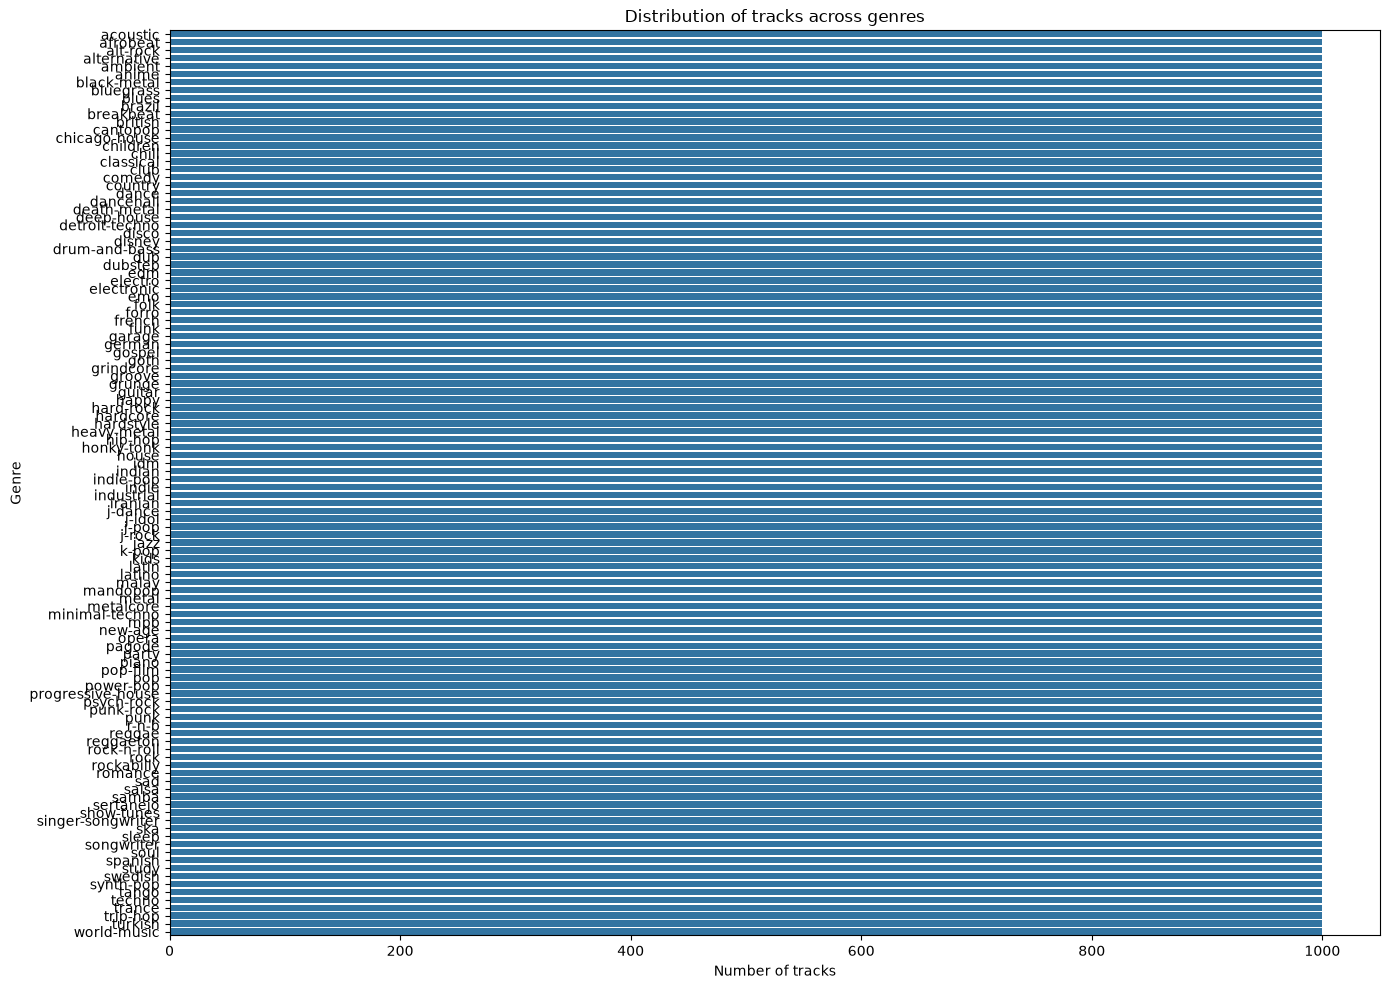

In [8]:
genre_counts = df['track_genre'].value_counts()

plt.figure(figsize=(14, 10))

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index
)

plt.title('Distribution of tracks across genres')
plt.xlabel('Number of tracks')
plt.ylabel('Genre')

plt.tight_layout()
plt.show()

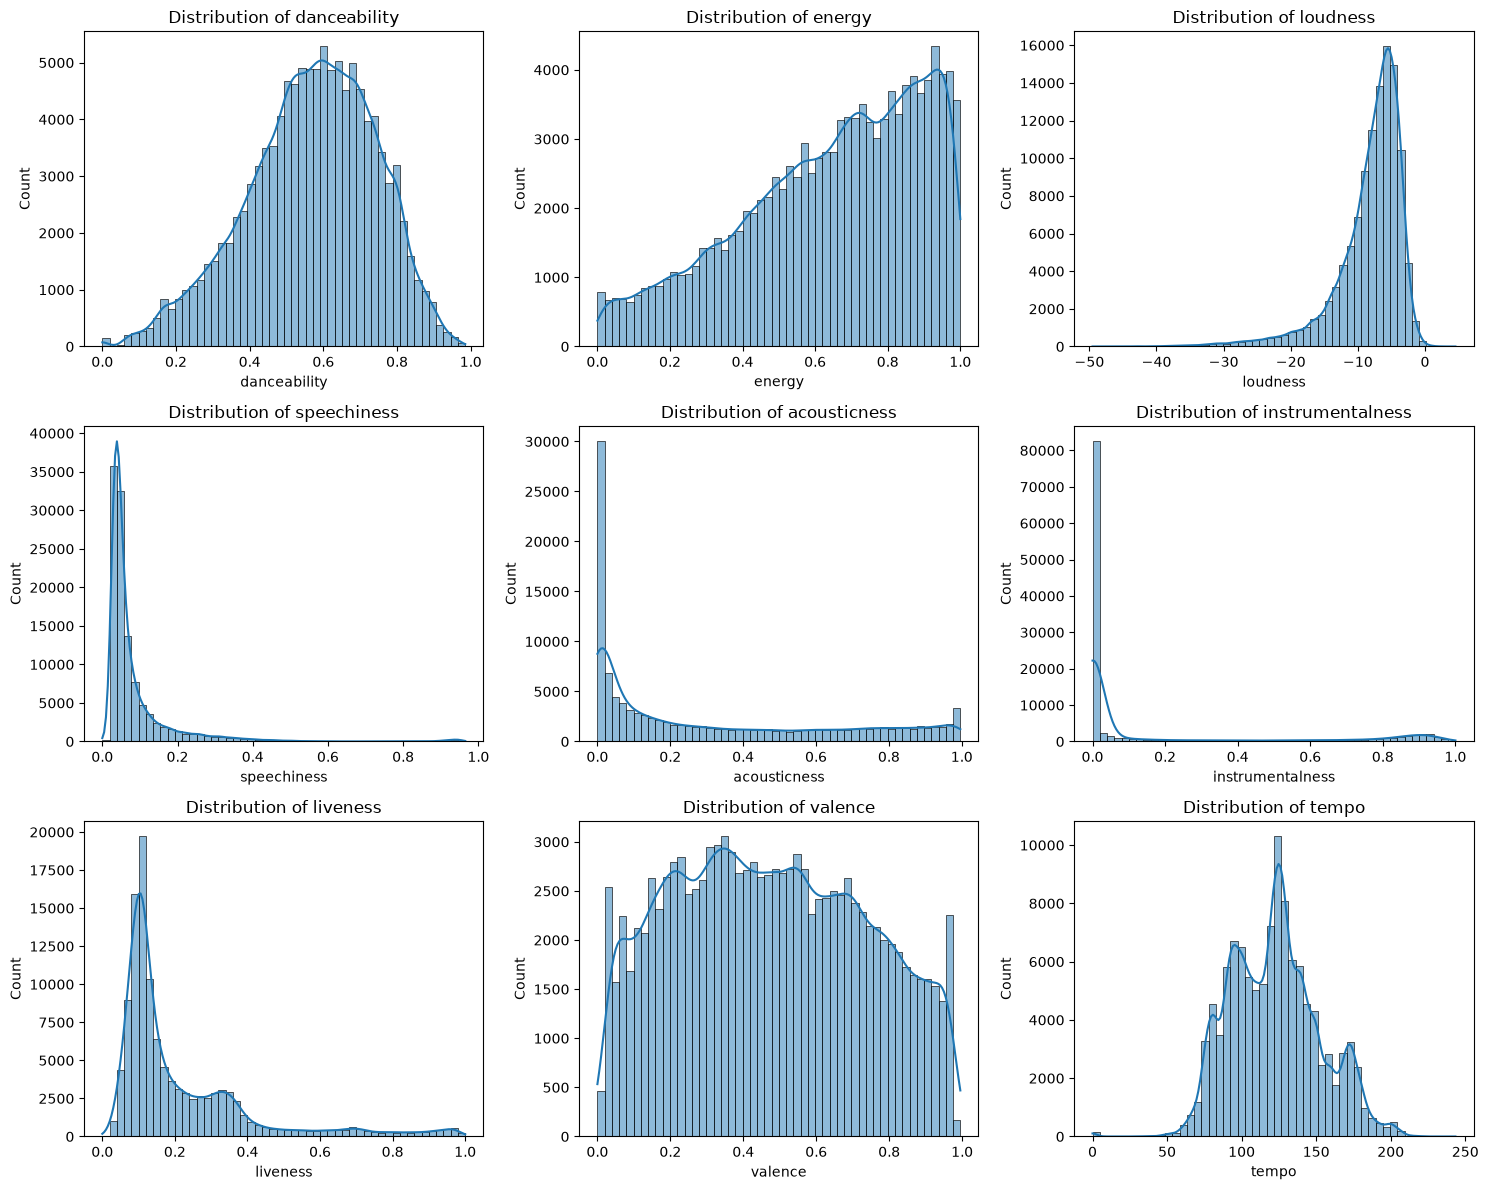

In [9]:
# Визуализация распределений числовых признаков
num_cols = ['danceability', 'energy', 'loudness', 'speechiness', 
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i, col in enumerate(num_cols):
    row, col_idx = divmod(i, 3)
    sns.histplot(df[col], bins=50, kde=True, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('../data/processed/distributions.png')
plt.show()

Исследование №1 — действительно ли одинаковые track_id имеют одинаковые признаки

In [10]:
features = [
    'popularity',
    'duration_ms',
    'explicit',
    'danceability',
    'energy',
    'key',
    'loudness',
    'mode',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'time_signature'
]

feature_variation = (
    df.groupby('track_id')[features]
      .nunique()
)

print(feature_variation.max().sort_values(ascending=False))

popularity          2
duration_ms         1
explicit            1
danceability        1
energy              1
key                 1
loudness            1
mode                1
speechiness         1
acousticness        1
instrumentalness    1
liveness            1
valence             1
tempo               1
time_signature      1
dtype: int64


In [11]:
print(
    "Track ID с разными tempo:",
    (feature_variation['tempo'] > 1).sum()
)

print(
    "Track ID с разными audio features:",
    (feature_variation.drop(columns=['popularity', 'explicit', 'duration_ms', 'key', 'mode', 'time_signature']).max(axis=1) > 1).sum()
)

Track ID с разными tempo: 0
Track ID с разными audio features: 0


Исследование №2 — что происходит с одним треком в разных жанрах

In [12]:
multi_genre_ids = (
    df.groupby('track_id')['track_genre']
      .nunique()
      .loc[lambda x: x > 1]
      .index
)

example_ids = multi_genre_ids[:5]

df[df['track_id'].isin(example_ids)][
    ['track_id', 'track_name', 'artists', 'track_genre',
     'danceability', 'energy', 'tempo']
].sort_values('track_id')

,track_id,track_name,artists,track_genre,danceability,energy,tempo
15028,001APMDOl3qtx1526T11n1,Better,Pink Sweat$;Kirby,chill,0.613,0.471,143.064
103211,001APMDOl3qtx1526T11n1,Better,Pink Sweat$;Kirby,soul,0.613,0.471,143.064
85578,001YQlnDSduXd5LgBd66gT,El Tiempo Es Dinero - Remasterizado 2007,Soda Stereo,punk-rock,0.554,0.921,183.571
100420,001YQlnDSduXd5LgBd66gT,El Tiempo Es Dinero - Remasterizado 2007,Soda Stereo,ska,0.554,0.921,183.571
2106,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,alt-rock,0.352,0.911,148.033
3257,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,alternative,0.352,0.911,148.033
91801,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,rock,0.352,0.911,148.033
33178,004h8smbIoAkUNDJvVKwkG,Lovemark,Ouse;Powfu,emo,0.808,0.331,140.035
94239,004h8smbIoAkUNDJvVKwkG,Lovemark,Ouse;Powfu,sad,0.808,0.331,140.035
35138,006rHBBNLJMpQs8fRC2GDe,Agora Estou Sofrendo - Ao Vivo,Calcinha Preta;Gusttavo Lima,forro,0.605,0.678,125.059


Исследование №3 — сколько именно tempo = 0 и loudness

In [13]:
print("loudness > 0:", (df['loudness'] > 0).sum())

print(
    df[df['loudness'] > 0][
        ['track_name', 'artists', 'loudness', 'track_genre']
    ].head(20)
)

loudness > 0: 90
                                 track_name                           artists  \
5307                            それは小さな光のような                            Sayuri   
5710                            それは小さな光のような                            Sayuri   
10033               Stigma - Burr Oak Remix                   Noisia;Burr Oak   
10137         Ganja - Deekline & Kleu Remix         Dub Pistols;Deekline;Kleu   
10705                                 STARS                           DJ Fixx   
10907        Get Lucky - Nick The Lot Remix  Deekline;Specimen A;Nick The Lot   
17574                            Fate Dance                   Five Star Hotel   
17590                 Eternity or Something                      Free Refills   
17788                              The Mall                      Free Refills   
17886                              Silicone                      Free Refills   
17895                           Malfunction                      Free Refills   
20904      

tempo = 0 нужно исследовать
проверяю, есть ли что-то между 0 и 50, чтобы понять, это зафиксировали ошибку или итс окей

In [14]:
print("tempo = 0:", (df['tempo'] == 0).sum())

print(
    df[df['tempo'] == 0][
        ['track_id', 'track_name', 'artists', 'tempo', 'track_genre']
    ].head(20)
)

print(
    df[df['tempo'] < 50]['tempo']
    .value_counts()
    .sort_index()
    .head(20)
)

tempo = 0: 157
                      track_id  \
4131    59gg6zQhSKGVnkT3hWAY3l   
4379    4acmzQsAeMJa5sGFSog7fu   
4664    1Kb2DqjHRvOcT5xeWtz3t5   
45670   6B9Mgf9smWqxDjA35VD6MK   
45720   7i5OoyPXtSrqz9jobJfG1F   
45729   0pTAEdockvKVSq1hhFqk7O   
45773   1keWmyG6qyBbMagPBdgUKr   
59221   5BcyxCXrXuw4vsAqAiObWM   
59310   6hsyfegVY5yklJneM40mWi   
59473   48Nt8u7kYSTwE6axtE9hJO   
59812   38Ogh3rsHba83kXx13gbKs   
64826   63kd4m3VFxcJjPVVtbVNAu   
76716   7KHG8MHzxAv0YnLFBWY9Y1   
76736   0q0r8JVp4dPZBbmBUsqsgO   
93111   1JihKsZjTyaqh0sPpOJqxW   
98779   2ObXcpK0NlkbEpjLXHZJn4   
101041  4TZh9HGsgaH3qzX40TPsF3   
101043  4xu38KnbRHbRHRwdg4KFul   
101048  1ATNhuJASoNNIcGb1eoQGP   
101057  5oeF42L73APoIognQDfqsS   

                                               track_name  \
4131                                        The Departure   
4379            The End of Childhood (feat. Jack Liebeck)   
4664                                       Ferme Les Yeux   
45670                     

Посмотрим, насколько часто один трек встречается в нескольких жанрах

In [15]:
track_genres = (
    df.groupby('track_id')['track_genre']
      .agg(list)
)

print(track_genres[track_genres.apply(len) > 1].head(20))
print(
    track_genres
    .apply(len)
    .value_counts()
    .sort_index()
)

track_id
001APMDOl3qtx1526T11n1                                        [chill, soul]
001YQlnDSduXd5LgBd66gT                                     [punk-rock, ska]
003vvx7Niy0yvhvHt4a68B                        [alt-rock, alternative, rock]
004h8smbIoAkUNDJvVKwkG                                           [emo, sad]
006rHBBNLJMpQs8fRC2GDe                           [forro, pagode, sertanejo]
006tmNZLXEXPqdb23wwSN1                       [j-pop, j-rock, jazz, turkish]
00970cTs7LnxWt0d5Qk08m                                        [blues, jazz]
00B7SBwrjbycLMOgAmeIU8                              [alt-rock, funk, metal]
00EsQxsJv6vy7hEQN3jZWG                      [singer-songwriter, songwriter]
00GVRTIWMjYwwHEjTLclgf                      [chicago-house, detroit-techno]
00IiTu5o9IVasXMX3udpZo                                    [punk-rock, punk]
00JZ83w0Qm09f4PwWj06sM                             [honky-tonk, honky-tonk]
00KfIFi2TpAaQGPbRbFbKJ                         [alternative, grunge, metal]
00L

Блок покажет, какие жанры остаются после удаления неоднозначных треков.

In [16]:
# Сколько жанров у каждого трека
track_genre_count = (
    df.groupby('track_id')['track_genre']
      .nunique()
)

# ID треков, у которых только один жанр
single_genre_ids = track_genre_count[
    track_genre_count == 1
].index

# Оставляем только однозначно размеченные треки
df_single = df[
    df['track_id'].isin(single_genre_ids)
].copy()

print("Исходный размер:", df.shape)
print("После отбора:", df_single.shape)
print("Уникальных треков:", df_single['track_id'].nunique())
print("Жанров:", df_single['track_genre'].nunique())

print("\nРаспределение жанров:")
print(df_single['track_genre'].value_counts())

print(
    df_single.groupby('track_genre')['track_id'].nunique().describe()
)

Исходный размер: (114000, 21)
После отбора: (73790, 21)
Уникальных треков: 73442
Жанров: 112

Распределение жанров:
track_genre
iranian       1000
romance       1000
study         1000
honky-tonk     999
tango          999
              ... 
latino         144
edm            129
indie          121
reggae          87
reggaeton       72
Name: count, Length: 112, dtype: int64
count    112.000000
mean     655.732143
std      269.327223
min       72.000000
25%      451.750000
50%      696.500000
75%      884.250000
max      999.000000
Name: track_id, dtype: float64


мы увидим, какие жанры особенно сильно пересекаются с другими жанрами

In [17]:
genre_comparison = pd.DataFrame({
    'original': df['track_genre'].value_counts(),
    'single_genre': df_single['track_genre'].value_counts()
})

genre_comparison['remaining_pct'] = (
    genre_comparison['single_genre']
    / genre_comparison['original']
    * 100
)

print(
    genre_comparison
    .sort_values('remaining_pct')
    .head(20)
)

print(
    genre_comparison
    .sort_values('remaining_pct', ascending=False)
    .head(20)
)

             original  single_genre  remaining_pct
track_genre                                       
reggaeton        1000          72.0            7.2
reggae           1000          87.0            8.7
indie            1000         121.0           12.1
edm              1000         129.0           12.9
latino           1000         144.0           14.4
metal            1000         151.0           15.1
alternative      1000         158.0           15.8
alt-rock         1000         159.0           15.9
house            1000         190.0           19.0
dub              1000         202.0           20.2
punk             1000         208.0           20.8
latin            1000         232.0           23.2
punk-rock        1000         246.0           24.6
indie-pop        1000         261.0           26.1
dubstep          1000         268.0           26.8
rock             1000         274.0           27.4
brazil           1000         279.0           27.9
j-rock           1000         3

FULL DATASET
Строк: 114,000
Уникальных track_id: 89,741
Жанров: 114

SINGLE-GENRE DATASET
Строк: 73,790
Уникальных track_id: 73,442
Жанров: 112

Размер классов:
count     112.000000
mean      658.839286
std       271.162082
min        72.000000
25%       455.250000
50%       702.000000
75%       886.000000
max      1000.000000
Name: count, dtype: float64


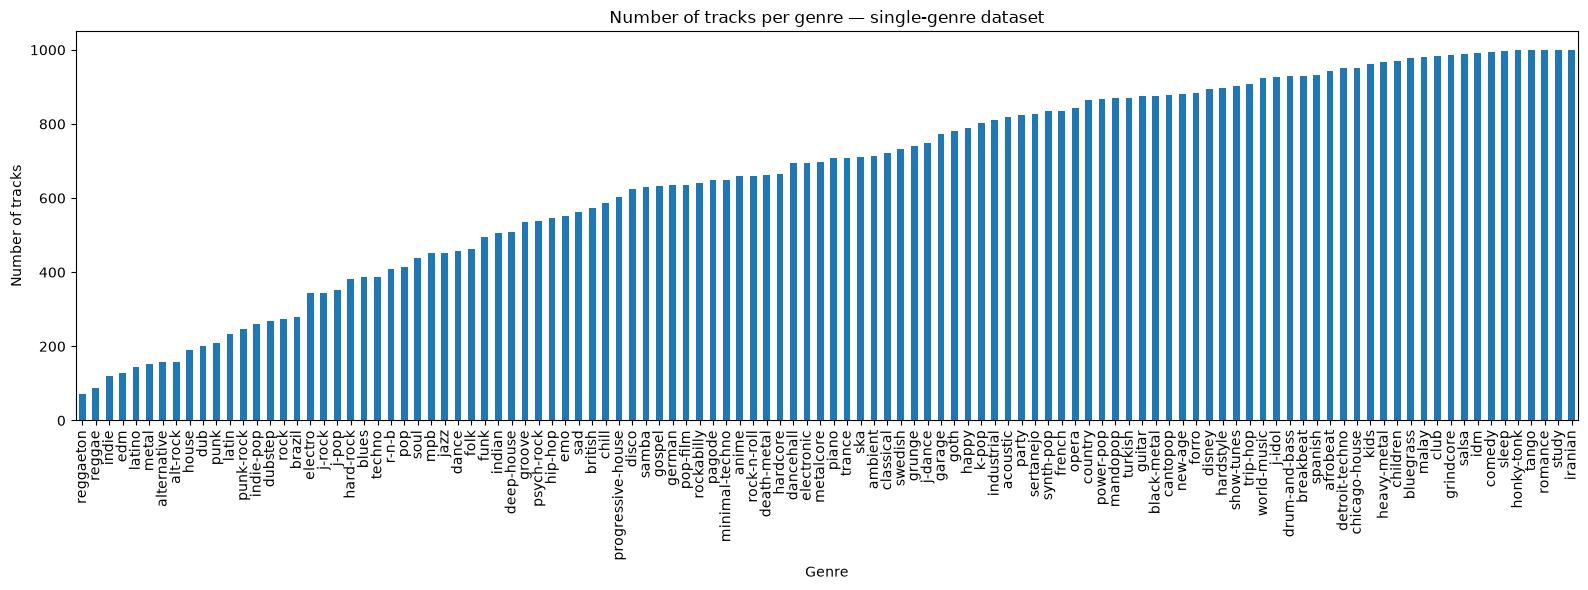

In [18]:
print("FULL DATASET")
print(f"Строк: {len(df):,}")
print(f"Уникальных track_id: {df['track_id'].nunique():,}")
print(f"Жанров: {df['track_genre'].nunique()}")

print("\nSINGLE-GENRE DATASET")
print(f"Строк: {len(df_single):,}")
print(f"Уникальных track_id: {df_single['track_id'].nunique():,}")
print(f"Жанров: {df_single['track_genre'].nunique()}")

print("\nРазмер классов:")
print(df_single['track_genre'].value_counts().describe())


import matplotlib.pyplot as plt

genre_counts = df_single['track_genre'].value_counts()

plt.figure(figsize=(16, 6))
genre_counts.sort_values().plot(kind='bar')
plt.title('Number of tracks per genre — single-genre dataset')
plt.xlabel('Genre')
plt.ylabel('Number of tracks')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


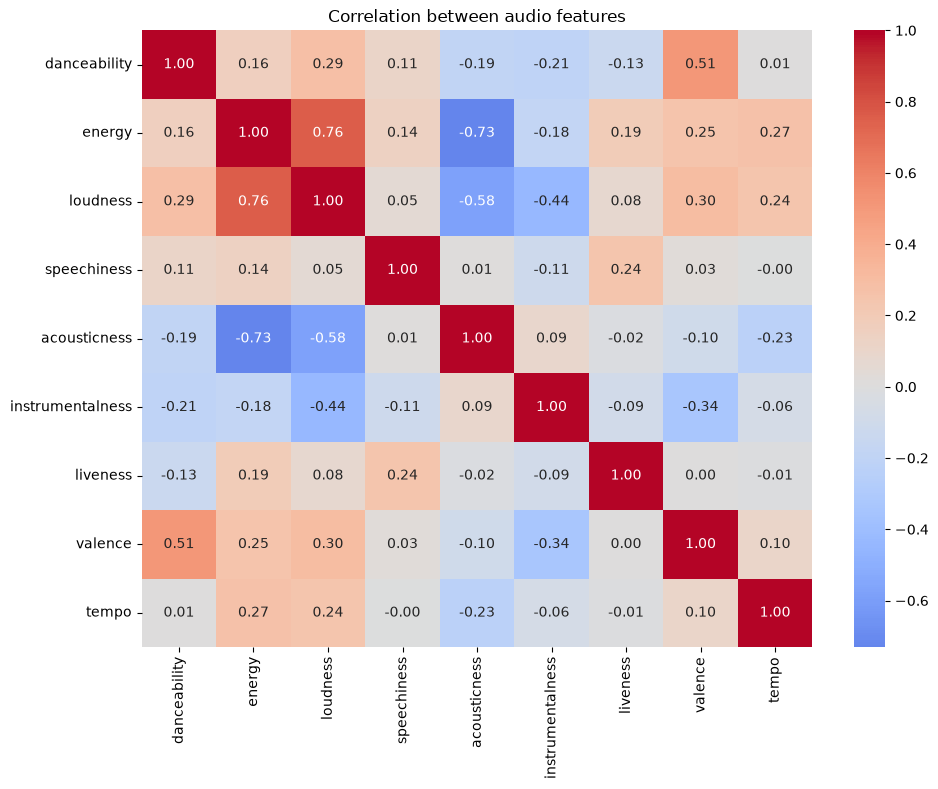

In [19]:
audio_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

corr_matrix = df_single[audio_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Correlation between audio features')
plt.tight_layout()
plt.show()

In [20]:
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

print(corr_pairs.head(15))

energy            loudness            0.757269
                  acousticness       -0.731201
loudness          acousticness       -0.577629
danceability      valence             0.510108
loudness          instrumentalness   -0.435701
instrumentalness  valence            -0.337144
loudness          valence             0.299767
danceability      loudness            0.289262
energy            tempo               0.269008
                  valence             0.254826
speechiness       liveness            0.244438
loudness          tempo               0.243342
acousticness      tempo              -0.230671
danceability      instrumentalness   -0.207434
energy            liveness            0.191703
dtype: float64


In [21]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

X_vif = df_single[vif_features].copy()

vif = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif = vif.sort_values('VIF', ascending=False)

print(vif)

            feature       VIF
1            energy  4.231224
2          loudness  3.264751
4      acousticness  2.408830
7           valence  1.608132
0      danceability  1.564757
5  instrumentalness  1.467900
6          liveness  1.172499
3       speechiness  1.157627
8             tempo  1.100125


In [22]:
print(df_single[vif_features].nunique())

danceability         1166
energy               2057
loudness            18741
speechiness          1479
acousticness         4993
instrumentalness     5293
liveness             1710
valence              1790
tempo               40850
dtype: int64


In [23]:
print(df_single[vif_features].std().sort_values())

speechiness          0.120212
danceability         0.180174
liveness             0.198233
energy               0.261559
valence              0.266136
instrumentalness     0.335786
acousticness         0.343945
loudness             5.413069
tempo               30.267182
dtype: float64


In [25]:
features = [
    'danceability',
    'energy',
    'key',
    'loudness',import pandas as pd
from pathlib import Path

data_path = Path('../data/processed')

files = [
    'cleaned_tracks.csv',
    'dataset_clean.csv',
    'dataset_clean_final.csv'
]

for file in files:
    path = data_path / file
    
    temp = pd.read_csv(path)
    
    print(f'\n===== {file} =====')
    print('Shape:', temp.shape)
    print('Columns:', list(temp.columns))
    print('Missing values:', temp.isna().sum().sum())
    print('Unique track_id:', temp['track_id'].nunique())
    print('Genres:', temp['track_genre'].nunique())
    'mode',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'time_signature'
]

X = df_single[features]
y = df_single['track_genre']

In [26]:
import pandas as pd
from pathlib import Path

data_path = Path('../data/processed')

files = [
    'cleaned_tracks.csv',
    'dataset_clean.csv',
    'dataset_clean_final.csv'
]

for file in files:
    path = data_path / file
    
    temp = pd.read_csv(path)
    
    print(f'\n===== {file} =====')
    print('Shape:', temp.shape)
    print('Columns:', list(temp.columns))
    print('Missing values:', temp.isna().sum().sum())
    print('Unique track_id:', temp['track_id'].nunique())
    print('Genres:', temp['track_genre'].nunique())


===== cleaned_tracks.csv =====
Shape: (113671, 22)
Columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'track_index']
Missing values: 0
Unique track_id: 89443
Genres: 114

===== dataset_clean.csv =====
Shape: (113999, 21)
Columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']
Missing values: 0
Unique track_id: 89740
Genres: 114

===== dataset_clean_final.csv =====
Shape: (113671, 21)
Columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 

In [27]:
df_clean = pd.read_csv('../data/processed/dataset_clean.csv')
df_final = pd.read_csv('../data/processed/dataset_clean_final.csv')

print('Удалено строк:', len(df_clean) - len(df_final))

# Какие строки есть в clean, но уже нет в final
removed = df_clean.loc[~df_clean.index.isin(df_final.index)]

print('\nКоличество удалённых строк:', len(removed))

print('\nLoudness удалённых:')
print(removed['loudness'].describe())

print('\nTempo удалённых:')
print(removed['tempo'].describe())

print('\nTempo < 50:', (removed['tempo'] < 50).sum())
print('Tempo > 250:', (removed['tempo'] > 250).sum())
print('Loudness > 0:', (removed['loudness'] > 0).sum())

Удалено строк: 328

Количество удалённых строк: 328

Loudness удалённых:
count    328.000000
mean     -10.697381
std        6.711096
min      -39.693000
25%      -12.070250
50%       -8.402500
75%       -6.495750
max       -3.090000
Name: loudness, dtype: float64

Tempo удалённых:
count    328.000000
mean     115.305198
std       32.687552
min        0.000000
25%       83.749500
50%      123.948500
75%      141.540750
max      207.881000
Name: tempo, dtype: float64

Tempo < 50: 3
Tempo > 250: 0
Loudness > 0: 0
